
=== Model Comparison ===
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.973684   0.972222 0.985915  0.979021
      Random Forest  0.964912   0.958904 0.985915  0.972222
            XGBoost  0.956140   0.958333 0.971831  0.965035


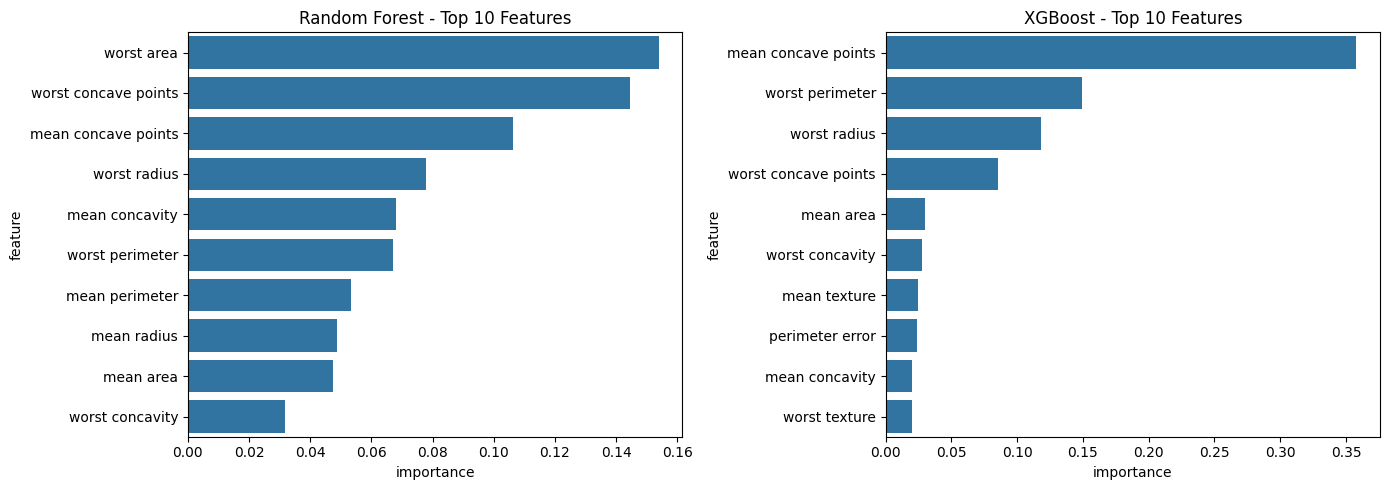

In [10]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train models
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# Evaluate
def evaluate(y_true, y_pred, name):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

results = pd.DataFrame([
    evaluate(y_test, y_pred_lr, 'Logistic Regression'),
    evaluate(y_test, y_pred_rf, 'Random Forest'),
    evaluate(y_test, y_pred_xgb, 'XGBoost')
])

print("\n=== Model Comparison ===")
print(results.to_string(index=False))

# Feature importance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
rf_imp = pd.DataFrame({'feature': data.feature_names, 'importance': rf.feature_importances_}).sort_values('importance', ascending=False).head(10)
xgb_imp = pd.DataFrame({'feature': data.feature_names, 'importance': xgb.feature_importances_}).sort_values('importance', ascending=False).head(10)

sns.barplot(data=rf_imp, x='importance', y='feature', ax=ax1)
ax1.set_title('Random Forest - Top 10 Features')
sns.barplot(data=xgb_imp, x='importance', y='feature', ax=ax2)
ax2.set_title('XGBoost - Top 10 Features')
plt.tight_layout()
plt.show()

In [9]:
from google.colab import files

files.download("titanic_ml_pipeline.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>